# 02 — Detected regimes and filtered probabilities (SPY)

Out-of-sample regime labels and *filtered* state probabilities from the walk-forward 2-state Gaussian HMM, plus agreement with the volatility heuristic. Labels at date *t* use information up to *t* only (smoothed probabilities are never used for trading).

In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from regimelab import plotting

FIG = ROOT / "reports" / "figures"
OUT = ROOT / "experiments" / "outputs" / "comparison_spy"
hmm = pd.read_csv(OUT / "regimes_hmm2.csv", index_col=0, parse_dates=True)["SPY"]
vol = pd.read_csv(OUT / "regimes_vol20q80.csv", index_col=0, parse_dates=True)["SPY"]
probs = pd.read_csv(OUT / "probs_hmm2.csv", index_col=0, header=[0, 1], parse_dates=True)
prices = pd.read_csv(ROOT / "data" / "raw" / "SPY.csv", index_col=0, parse_dates=True)["close"]
p_turbulent = probs[("SPY", probs["SPY"].columns[-1])]  # highest-variance state
oos_prices = prices.reindex(hmm.index)
f"OOS {hmm.index.min().date()} → {hmm.index.max().date()}, turbulent share {hmm.mean():.1%}"

'OOS 2005-01-07 → 2026-06-09, turbulent share 21.0%'

PosixPath('/Users/mohamedryad/Desktop/RegimeLab/reports/figures/spy_hmm2_regimes.png')

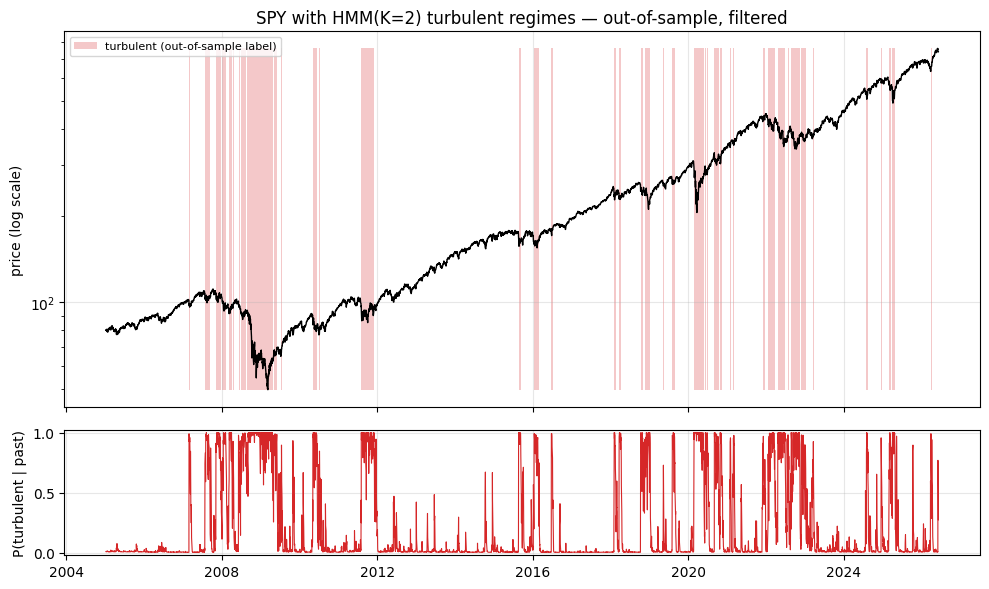

In [2]:
fig = plotting.regime_overlay(
    oos_prices, hmm, turbulent_probability=p_turbulent,
    title="SPY with HMM(K=2) turbulent regimes — out-of-sample, filtered",
)
plotting.save_figure(fig, FIG / "spy_hmm2_regimes.png")

In [3]:
# Do the heuristic and the HMM see the same regimes?
agreement = (hmm == vol).mean()
crosstab = pd.crosstab(vol.rename("vol_gate"), hmm.rename("hmm2"), normalize=True)
print(f"label agreement: {agreement:.1%}")
crosstab.round(3)

label agreement: 90.4%


hmm2,0.0,1.0
vol_gate,,
0.0,0.773,0.079
1.0,0.017,0.131


**Reading.** Turbulent labels concentrate exactly where they should — 2008–09, the 2011 and 2015–16 corrections, March 2020, 2022. The HMM flags more days than the vol filter (~21% vs ~15%) and the two agree on most dates; disagreements are mostly moderate-volatility days near regime edges, where the filtered probability hovers around 0.5 — visible as flicker in the probability panel. That flicker is what the no-trade band (notebook 03) is designed to absorb.